Task 1: Simple Linear Regression  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("/content/ai4i2020.csv")

In [3]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [4]:
X = df[['Rotational speed [rpm]']]
y = df['Process temperature [K]']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 2.1691240317336407


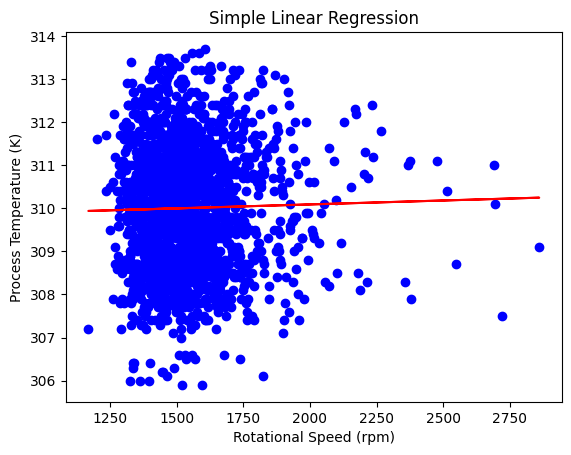

In [9]:
plt.scatter(X_test, y_test, color='blue')

plt.plot(X_test, y_pred, color='red')

plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Process Temperature (K)")
plt.title("Simple Linear Regression")

plt.show()

Task 2: Multivariable Regression  

In [10]:
X = df[[
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Air temperature [K]'
]]

y = df['Process temperature [K]']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred_multi = multi_model.predict(X_test)

In [14]:
multi_mse = mean_squared_error(y_test, y_pred_multi)

print("Multivariable Regression MSE:", multi_mse)

Multivariable Regression MSE: 0.5298708765361675


In [15]:
print("Simple Regression MSE :", mse)

print("Multivariable Regression MSE :", multi_mse)

Simple Regression MSE : 2.1691240317336407
Multivariable Regression MSE : 0.5298708765361675


In [16]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_
})

print(coefficients)

                  Feature  Coefficient
0  Rotational speed [rpm]    -0.000099
1             Torque [Nm]    -0.002450
2         Tool wear [min]    -0.000066
3     Air temperature [K]     0.651688


Task 3: Save Model

In [17]:
import joblib

In [18]:
joblib.dump(multi_model, "temperature_predictor.pkl")

['temperature_predictor.pkl']

In [19]:
print("Model saved successfully!")

Model saved successfully!


In [21]:
import joblib
import numpy as np

# Load saved model
model = joblib.load("temperature_predictor.pkl")

# Feature order:
# [Rotational speed [rpm], Torque [Nm],
#  Tool wear [min], Air temperature [K]]

new_machine_data = np.array([[1550, 45, 120, 300]])

# Predict temperature
prediction = model.predict(new_machine_data)

print(f"Predicted Process Temperature: {prediction[0]:.2f} K")

Predicted Process Temperature: 309.99 K


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Task 4: One-Hot Encoding

In [22]:
print(df['Type'].unique())

['M' 'L' 'H']


In [23]:
encoded_df = pd.get_dummies(df, columns=['Type'])

In [24]:
print(encoded_df.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  Type_H  Type_L  Type_M  
0    0    0    0    0   False   False    True  
1    0    0   

In [25]:
encoded_df = pd.get_dummies(
    df,
    columns=['Type'],
    drop_first=True
)

Task 5: Train-Test Split  

In [26]:
X = encoded_df[[
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Air temperature [K]',
    'Type_M',
    'Type_L'
]]

y = encoded_df['Process temperature [K]']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (8000, 6)
Testing Features Shape: (2000, 6)
Training Target Shape: (8000,)
Testing Target Shape: (2000,)


In [29]:
from sklearn.linear_model import LinearRegression

split_model = LinearRegression()

split_model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = split_model.predict(X_test)

In [31]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Test Mean Squared Error:", mse)

Test Mean Squared Error: 0.5305603733573011


Task 6: Logistic Regression

In [32]:
X = encoded_df[[
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Air temperature [K]',
    'Type_M',
    'Type_L'
]]

y = encoded_df['Machine failure']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_pred = log_model.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1930    9]
 [  43   18]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000

